In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize_scalar
from g3m import calculate_G3M_expected_fee, calculate_G3M_expected_pool_value

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
    
def plot_fee_difference_by_sigma_w_gamma(df):
    """
    Create 9 subplots (one for each sigma) showing outgoing_fee - incoming_fee
    vs gamma for different w values
    """

    # Calculate fee difference (outgoing - incoming)
    df['fee_difference'] = df['outgoing_fee'] - df['incoming_fee']
        
    # Get unique values
    sigma_values = sorted(df['sigma'].unique())
    w_values = sorted(df['w'].unique())
        
    print(f"Found {len(sigma_values)} sigma values: {sigma_values}")
    print(f"Found {len(w_values)} w values: {w_values}")
        
    # Create 3x3 subplot grid with more space for legend
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    axes = axes.flatten()
        
    # Color palette for different w values
    colors = plt.cm.tab10(np.linspace(0, 1, len(w_values)))
        
    # Store legend handles and labels
    legend_handles = []
    legend_labels = []
        
    for i, sigma in enumerate(sigma_values):
        ax = axes[i]
            
        # Filter data for this sigma
        sigma_data = df[df['sigma'] == sigma]
            
        # Plot each w value as a different line
        for j, w in enumerate(w_values):
            w_data = sigma_data[sigma_data['w'] == w].sort_values('gamma')
                
            if len(w_data) > 0:
                if w == 0.5:
                    line = ax.plot(w_data['gamma'], w_data['fee_difference'], 
                        color=colors[j], label=f'w={w:.1f}', linewidth=2, alpha=0.8, linestyle='--')
                else:
                    line = ax.plot(w_data['gamma'], w_data['fee_difference'], 
                        color=colors[j], label=f'w={w:.1f}', linewidth=2, alpha=0.8)
                
                # Collect legend info from first subplot
                if i == 0:
                    legend_handles.extend(line)
                    legend_labels.append(f'w={w:.1f}')
            
        # Formatting
        ax.set_xlabel('Fee Rate (γ)', fontsize=11)
        ax.set_ylabel('Outgoing Fee - Incoming Fee', fontsize=11)
        ax.set_title(f'σ = {sigma:.1f}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
    # Remove any unused subplots
    for i in range(len(sigma_values), len(axes)):
        fig.delaxes(axes[i])
    
    # Add single legend to the right of all subplots with larger font and better spacing
    fig.legend(legend_handles, legend_labels, 
              loc='center right', bbox_to_anchor=(0.96, 0.5), 
              fontsize=16, frameon=True, fancybox=True, shadow=True,
              title='Weight (w)', title_fontsize=18,
              borderpad=1.5, columnspacing=1.0, handlelength=2.5,
              handletextpad=1.0, labelspacing=1.2)
    
    # Add title with proper spacing
    fig.suptitle('Fee Difference (Outgoing - Incoming) by Volatility and Weight', 
                fontsize=20, fontweight='bold', y=0.98)
    
    # Adjust layout to make room for legend and title
    plt.subplots_adjust(left=0.08, right=0.82, top=0.93, bottom=0.08, 
                       hspace=0.3, wspace=0.3)
    plt.show()
    




In [30]:
def combined_G3M_analysis(metric='fee', L=1000000, pv0=2000000, fixed_pv=True, incoming_fee=True, gamma_for_sigma=0.0003):
    """
    Combined analysis showing both gamma and sigma sensitivity side by side with shared legend
    
    Args:
        metric: 'fee', 'pv', or 'tv' to specify what to plot
        L: Liquidity parameter
        pv0: Initial pool value
        fixed_pv: Whether to use fixed pool value
        incoming_fee: Whether to use incoming or outgoing fee
        gamma_for_sigma: The gamma value to use for sigma analysis plot
    """
    # Common parameters
    w_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    gamma_values = np.arange(0.00001, 0.001, 0.00001)
    sigma_values = np.arange(0.01, 1.0, 0.01)
    sigma_for_gamma = 0.5  # Fixed sigma for gamma analysis
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Set white background
    fig.patch.set_facecolor('white')
    ax1.set_facecolor('white')
    ax2.set_facecolor('white')
    
    # Loop through weight values for both plots
    lines = []  # Store lines for shared legend
    labels = []  # Store labels for shared legend
    
    for w in w_values:
        # Initialize arrays for both analyses
        fees_gamma = []
        pvs_gamma = []
        tvs_gamma = []
        fees_sigma = []
        pvs_sigma = []
        tvs_sigma = []
        
        # Calculate initial values
        if fixed_pv:
            x_t = (L/((1-w)*pv0)**(1-w))**(1/w)
            y_t = (1-w) * pv0
        else:
            x_t = y_t = 1
            
        S_t = (w/(1-w)) * (y_t/x_t)
        initial_value = x_t * S_t + y_t
        
        # First plot: Gamma sensitivity
        for gamma in gamma_values:
            incoming, outgoing = calculate_G3M_expected_fee(sigma=sigma_for_gamma, w=w, gamma=gamma, pv0=pv0, L=L)
            pv = calculate_G3M_expected_pool_value(sigma=sigma_for_gamma, w=w, gamma=gamma, pv0=pv0, L=L)
            fee = incoming if incoming_fee else outgoing
            
            fees_gamma.append(fee)
            pvs_gamma.append(pv)
            tvs_gamma.append(pv + fee - initial_value)
            
        # Second plot: Sigma sensitivity
        for sigma in sigma_values:
            incoming, outgoing = calculate_G3M_expected_fee(sigma=sigma, w=w, gamma=gamma_for_sigma, pv0=pv0, L=L)
            pv = calculate_G3M_expected_pool_value(sigma=sigma, w=w, gamma=gamma_for_sigma, pv0=pv0, L=L)
            fee = incoming if incoming_fee else outgoing
            
            fees_sigma.append(fee)
            pvs_sigma.append(pv)
            tvs_sigma.append(pv + fee - initial_value)
        
        # Plot style based on w=0.5
        style = '--' if w == 0.5 else '-'
        
        # Plot on appropriate subplot based on metric
        if metric == 'Net Gain':
            line1 = ax1.plot(gamma_values, tvs_gamma, linewidth=2, linestyle=style)[0]
            ax2.plot(sigma_values, tvs_sigma, linewidth=2, linestyle=style)
            ylabel = 'Expected TV'
        elif metric == 'Fee Revenue':
            line1 = ax1.plot(gamma_values, fees_gamma, linewidth=2, linestyle=style)[0]
            ax2.plot(sigma_values, fees_sigma, linewidth=2, linestyle=style)
            ylabel = 'Expected Fee'
        elif metric == 'Pool Value':
            line1 = ax1.plot(gamma_values, pvs_gamma, linewidth=2, linestyle=style)[0]
            ax2.plot(sigma_values, pvs_sigma, linewidth=2, linestyle=style)
            ylabel = 'Expected PV'
        
        # Store line and label for legend
        lines.append(line1)
        labels.append(f'w = {w:.1f}')
    
    # Set titles and labels with larger font sizes
    ax1.set_xlabel('Fee Rate (γ)', fontsize=16)
    ax1.set_ylabel(ylabel, fontsize=16)
    ax1.set_title(f'{metric} Sensitivity to Fee Rate (σ = {sigma_for_gamma})', 
                  fontsize=18, pad=15, fontweight='bold')
    
    ax2.set_xlabel('Volatility (σ)', fontsize=16)
    ax2.set_ylabel(ylabel, fontsize=16)
    ax2.set_title(f'{metric} Sensitivity to Volatility (γ = {gamma_for_sigma})', 
                  fontsize=18, pad=15, fontweight='bold')
    
    # Increase tick label sizes
    ax1.tick_params(axis='both', which='major', labelsize=14)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    
    # Add grid with white background
    ax1.grid(True, alpha=0.3, color='gray')
    ax2.grid(True, alpha=0.3, color='gray')
    
    # Add spines to separate title
    for ax in [ax1, ax2]:
        # Make top spine visible and thicker
        ax.spines['top'].set_visible(True)
        ax.spines['top'].set_linewidth(1.5)
        
        # Make other spines visible but thinner
        for spine in ['bottom', 'left', 'right']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(1)
    
    # Adjust layout first
    plt.tight_layout()
    
    # Add shared legend to the right of the subplots with adjusted position and larger font
    fig.legend(lines, labels, loc='center left', bbox_to_anchor=(0.98, 0.5), 
              fontsize=16, title='Weight Values', title_fontsize=16)
    
    # Fine-tune the spacing
    plt.subplots_adjust(right=0.98)
    
    plt.show()

In [35]:
def plot_net_gain_triple_heatmap(L=1000000, pv0=2000000, fixed_pv=True, w=0.5):
    """
    Create three heatmaps side by side showing:
    1. Incoming net gain
    2. Outgoing net gain
    3. Difference (Outgoing - Incoming)
    across different gamma and sigma values for a fixed weight.
    """
    # Parameters
    gamma_values = np.linspace(0.00001, 0.001, 20)  # Fee rate
    sigma_values = np.linspace(0.01, 1.0, 20)  # Volatility
    
    # Create meshgrid for plotting
    gamma_mesh, sigma_mesh = np.meshgrid(gamma_values, sigma_values)
    net_gain_incoming = np.zeros_like(gamma_mesh)
    net_gain_outgoing = np.zeros_like(gamma_mesh)
    
    # Calculate initial value
    if fixed_pv:
        x_t = (L/((1-w)*pv0)**(1-w))**(1/w)
        y_t = (1-w) * pv0
    else:
        x_t = y_t = 1
    
    S_t = (w/(1-w)) * (y_t/x_t)
    initial_value = x_t * S_t + y_t
    
    # Calculate net gains for each point
    for i, sigma in enumerate(sigma_values):
        for j, gamma in enumerate(gamma_values):
            incoming, outgoing = calculate_G3M_expected_fee(sigma=sigma, w=w, gamma=gamma, pv0=pv0, L=L)
            pv = calculate_G3M_expected_pool_value(sigma=sigma, w=w, gamma=gamma, pv0=pv0, L=L)
            
            net_gain_incoming[i,j] = pv + incoming - initial_value
            net_gain_outgoing[i,j] = pv + outgoing - initial_value
    
    # Calculate difference
    net_gain_diff = net_gain_incoming - net_gain_outgoing
    
    # Create figure with three subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
    
    # Find min and max for incoming/outgoing plots
    vmin_io = min(net_gain_incoming.min(), net_gain_outgoing.min())
    vmax_io = max(net_gain_incoming.max(), net_gain_outgoing.max())
    
    # Find min and max for difference plot
    vmin_diff = net_gain_diff.min()
    vmax_diff = net_gain_diff.max()
    
    # Plot incoming net gain
    im1 = ax1.imshow(net_gain_incoming, 
                     extent=[gamma_values[0], gamma_values[-1], 
                            sigma_values[0], sigma_values[-1]],
                     aspect='auto', origin='lower',
                     cmap='RdBu_r', vmin=vmin_io, vmax=vmax_io)
    
    # Plot outgoing net gain
    im2 = ax2.imshow(net_gain_outgoing, 
                     extent=[gamma_values[0], gamma_values[-1], 
                            sigma_values[0], sigma_values[-1]],
                     aspect='auto', origin='lower',
                     cmap='RdBu_r', vmin=vmin_io, vmax=vmax_io)
    
    # Plot difference
    im3 = ax3.imshow(net_gain_diff, 
                     extent=[gamma_values[0], gamma_values[-1], 
                            sigma_values[0], sigma_values[-1]],
                     aspect='auto', origin='lower',
                     cmap='RdBu_r')
    
    # Add colorbars
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar3 = plt.colorbar(im3, ax=ax3)
    cbar1.set_label('Incoming Net Gain', fontsize=12)
    cbar2.set_label('Outgoing Net Gain', fontsize=12)
    cbar3.set_label('Difference (Incoming - Outgoing)', fontsize=12)

    
    # Labels and titles
    for ax, title in zip([ax1, ax2, ax3], 
                        ['Incoming Net Gain', 'Outgoing Net Gain', 
                         'Difference (Incoming - Outgoing)']):
        ax.set_xlabel('Fee Rate (γ)', fontsize=12)
        ax.set_ylabel('Volatility (σ)', fontsize=12)
        ax.set_title(f'{title}\n(w = {w})', fontsize=14)
    
    plt.tight_layout()
    plt.show()

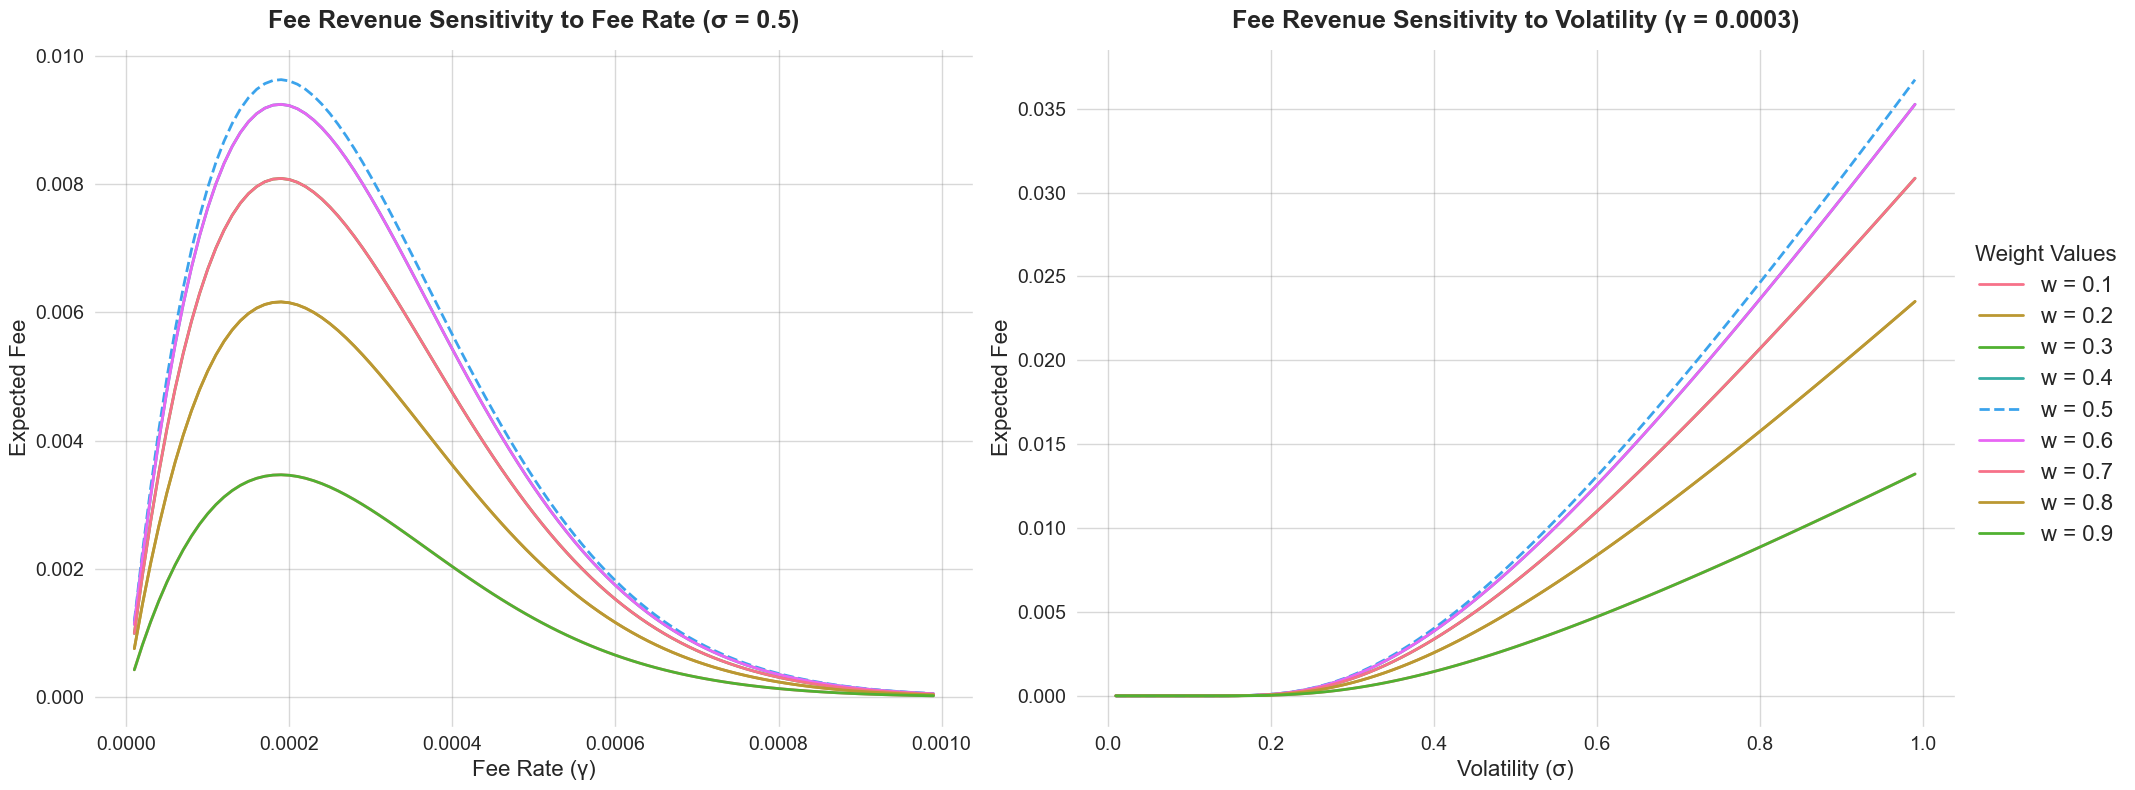

In [31]:
combined_G3M_analysis(metric='Fee Revenue')  # For fee analysis

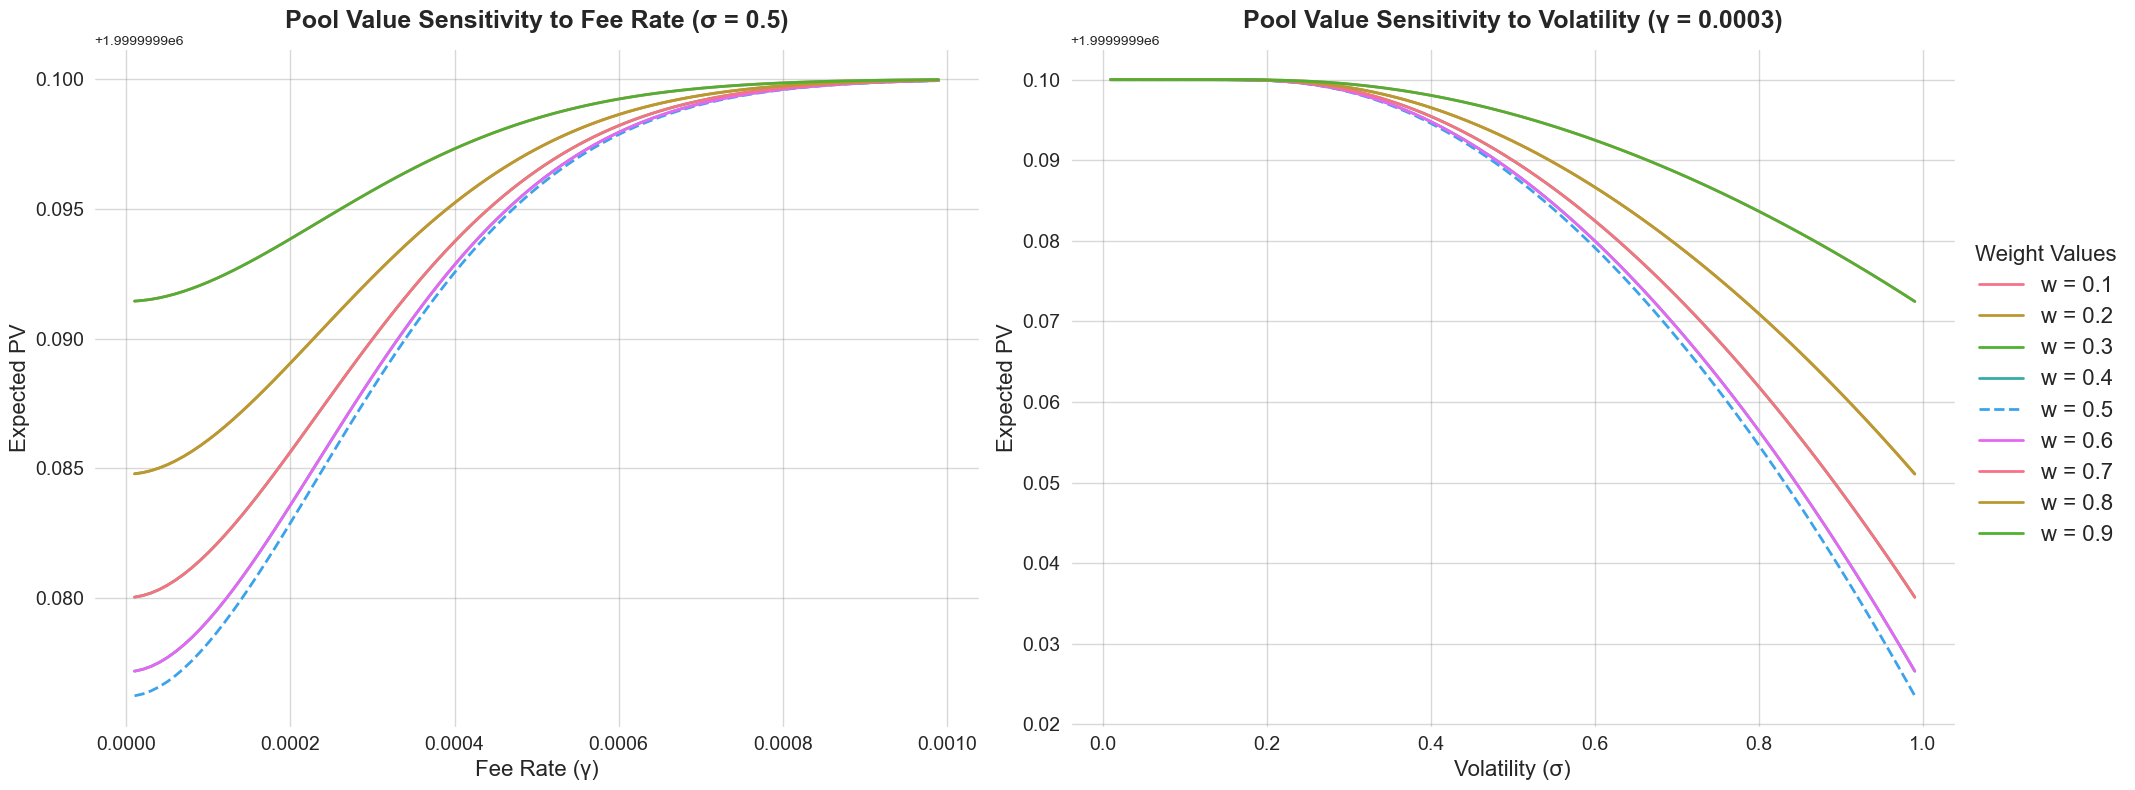

In [32]:
combined_G3M_analysis(metric='Pool Value') 


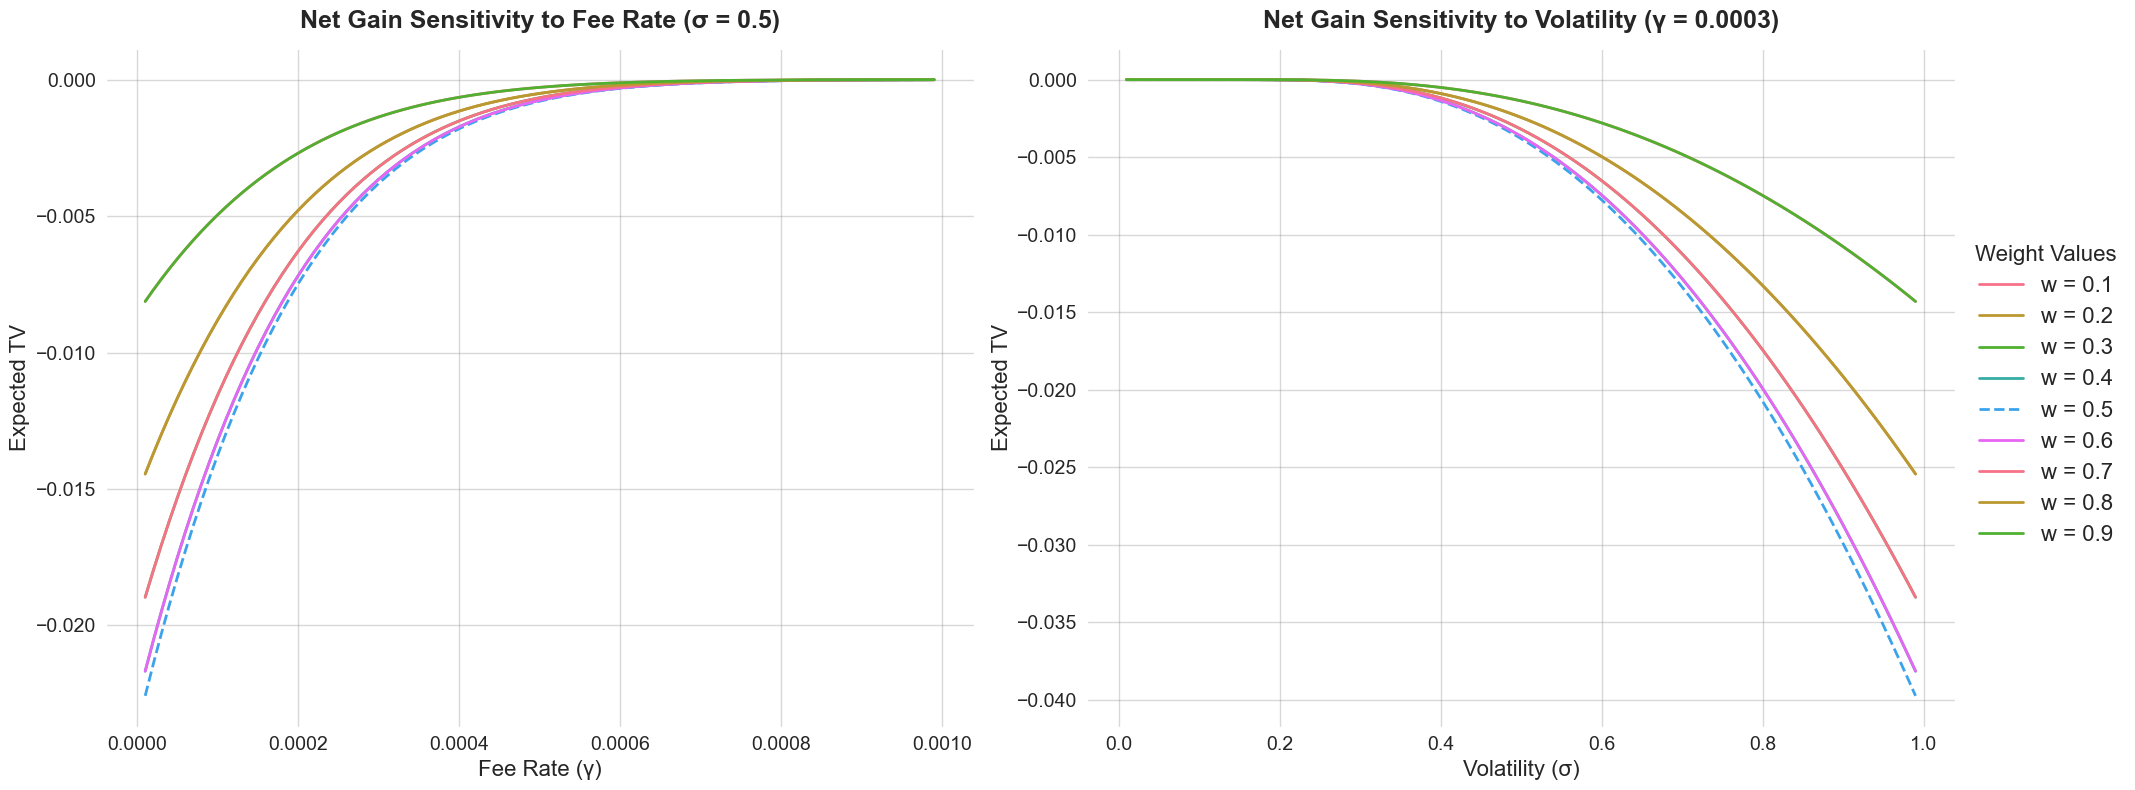

In [33]:
combined_G3M_analysis(metric='Net Gain') 

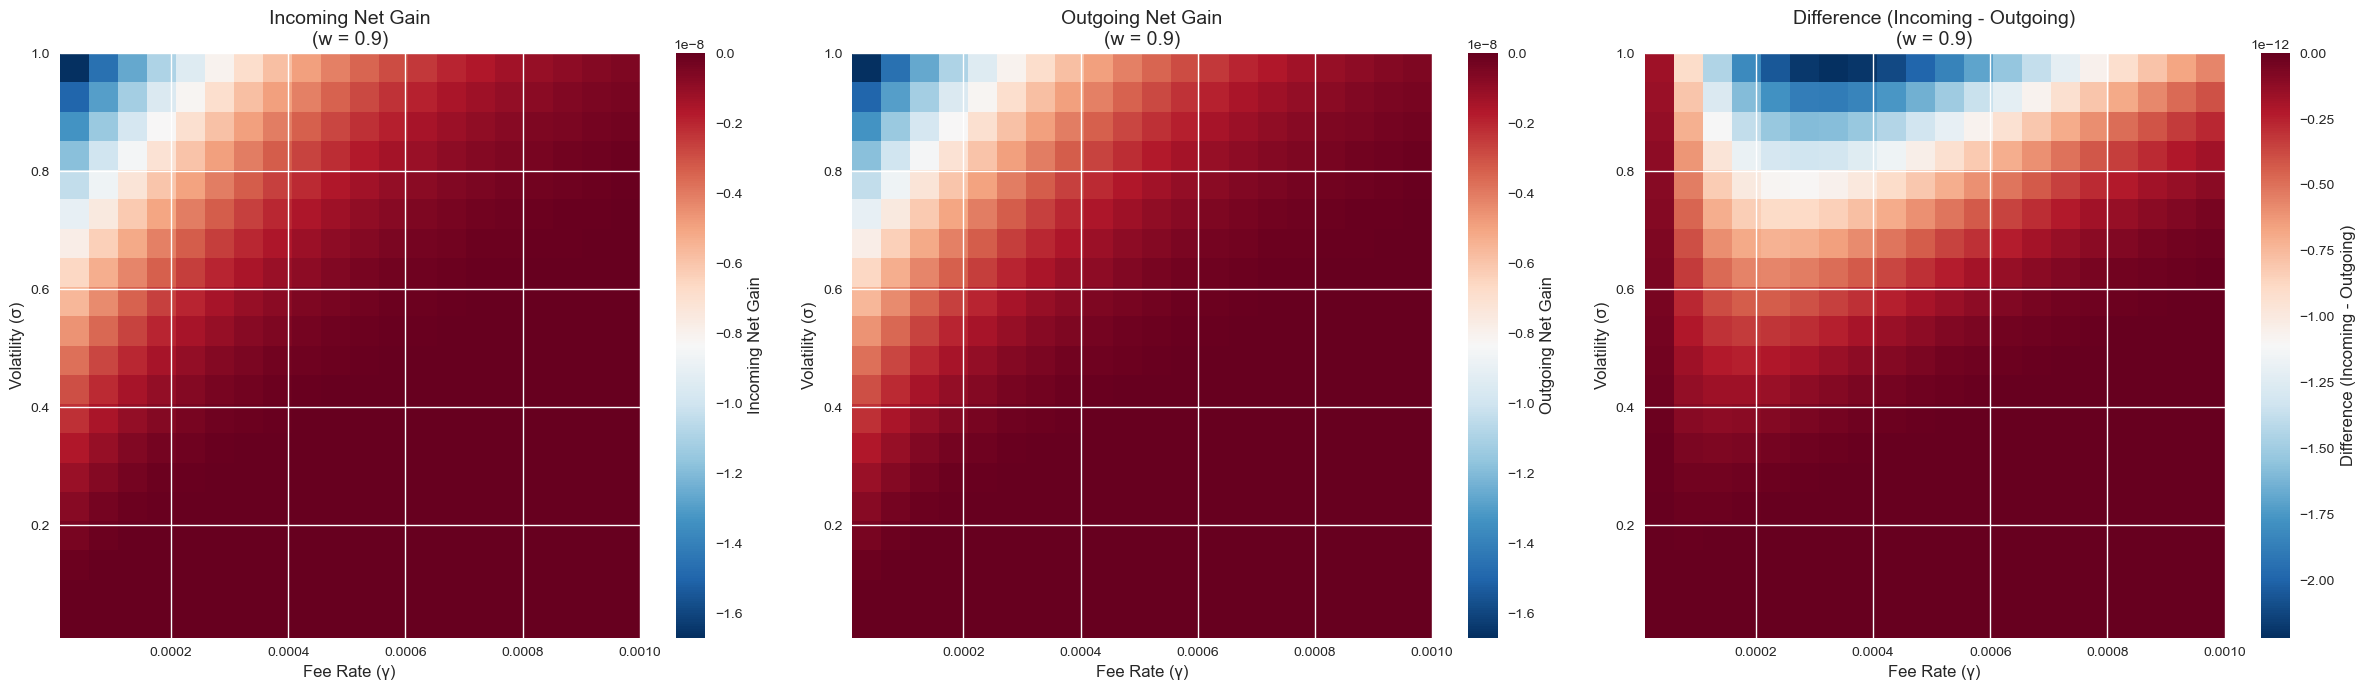

In [37]:
plot_net_gain_triple_heatmap(L=1e6, pv0=2e6, fixed_pv=True, w=0.9)

Processing combinations: 100%|██████████| 3969/3969 [00:00<00:00, 4028.73it/s]
/var/folders/f8/wwwwfy_x5tl686n3tb4qn5x40000gn/T/ipykernel_90509/1160811768.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


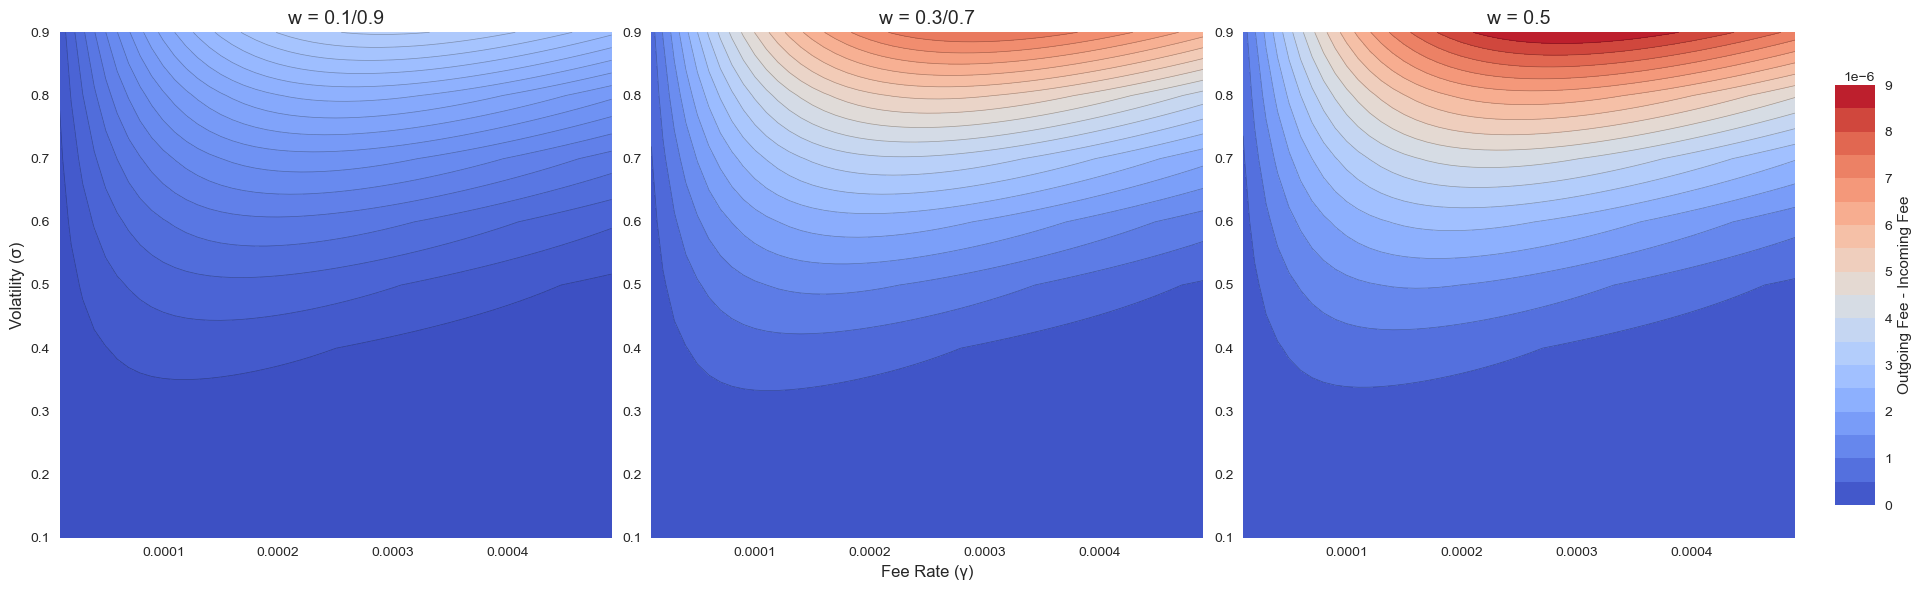

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

sigmas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
gammas = np.round(np.arange(0.00001, 0.0005, 0.00001), 5)
w_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
delta_t = 12/(365*24*60*60)
pv_0 = 2000000
L = 1000000
results = []
total_comb = len(sigmas) * len(w_values) * len(gammas)
progress_bar = tqdm(total=total_comb, desc="Processing combinations")

for sigma in sigmas:
    for w in w_values:
        for gamma in gammas:
            incoming_fee, outgoing_fee = calculate_G3M_expected_fee(sigma, w, gamma, pv_0, L, delta_t)
            results.append({
                'sigma': sigma,
                'w': w,
                'gamma': gamma,
                'incoming_fee': incoming_fee,
                'outgoing_fee': outgoing_fee
            })
            progress_bar.update(1)

progress_bar.close()

fee_df = pd.DataFrame(results)

# Calculate fee difference
fee_df['fee_difference'] = fee_df['outgoing_fee'] - fee_df['incoming_fee']

# Create figure with 1x3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define the w values we want to plot
w_pairs = [(0.1, 0.9), (0.3, 0.7), (0.5, 0.5)]

# Store min and max values for consistent colorbar scale
vmin = fee_df['fee_difference'].min()
vmax = fee_df['fee_difference'].max()

# Create subplots
for idx, (w, w_complement) in enumerate(w_pairs):
    ax = axes[idx]
    
    # Filter data for this w
    w_data = fee_df[fee_df['w'] == w]
    
    # Create pivot table for this w
    pivot_table = w_data.pivot_table(
        values='fee_difference',
        index='sigma',
        columns='gamma',
        aggfunc='mean'
    )
    
    # Create meshgrid
    sigma_vals = pivot_table.index.values
    gamma_vals = pivot_table.columns.values
    X, Y = np.meshgrid(gamma_vals, sigma_vals)
    
    # Create contour plot
    contour = ax.contourf(X, Y, pivot_table.values, levels=20, cmap='coolwarm',
                         vmin=vmin, vmax=vmax)
    
    # Add contour lines
    ax.contour(X, Y, pivot_table.values, levels=20, colors='k', alpha=0.3, linewidths=0.5)
    
    # Customize subplot
    if idx == 1:
        ax.set_xlabel('Fee Rate (γ)', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Volatility (σ)', fontsize=12)
    if w == 0.5:
        ax.set_title(f'w = {w:.1f}', fontsize=14)
    else:
        ax.set_title(f'w = {w:.1f}/{w_complement:.1f}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)

# Add colorbar to the right of the subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(contour, cax=cbar_ax, label='Outgoing Fee - Incoming Fee')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=0.9)

plt.show()


Processing combinations: 100%|██████████| 19845/19845 [00:05<00:00, 3908.89it/s]
/var/folders/f8/wwwwfy_x5tl686n3tb4qn5x40000gn/T/ipykernel_92517/2455969385.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


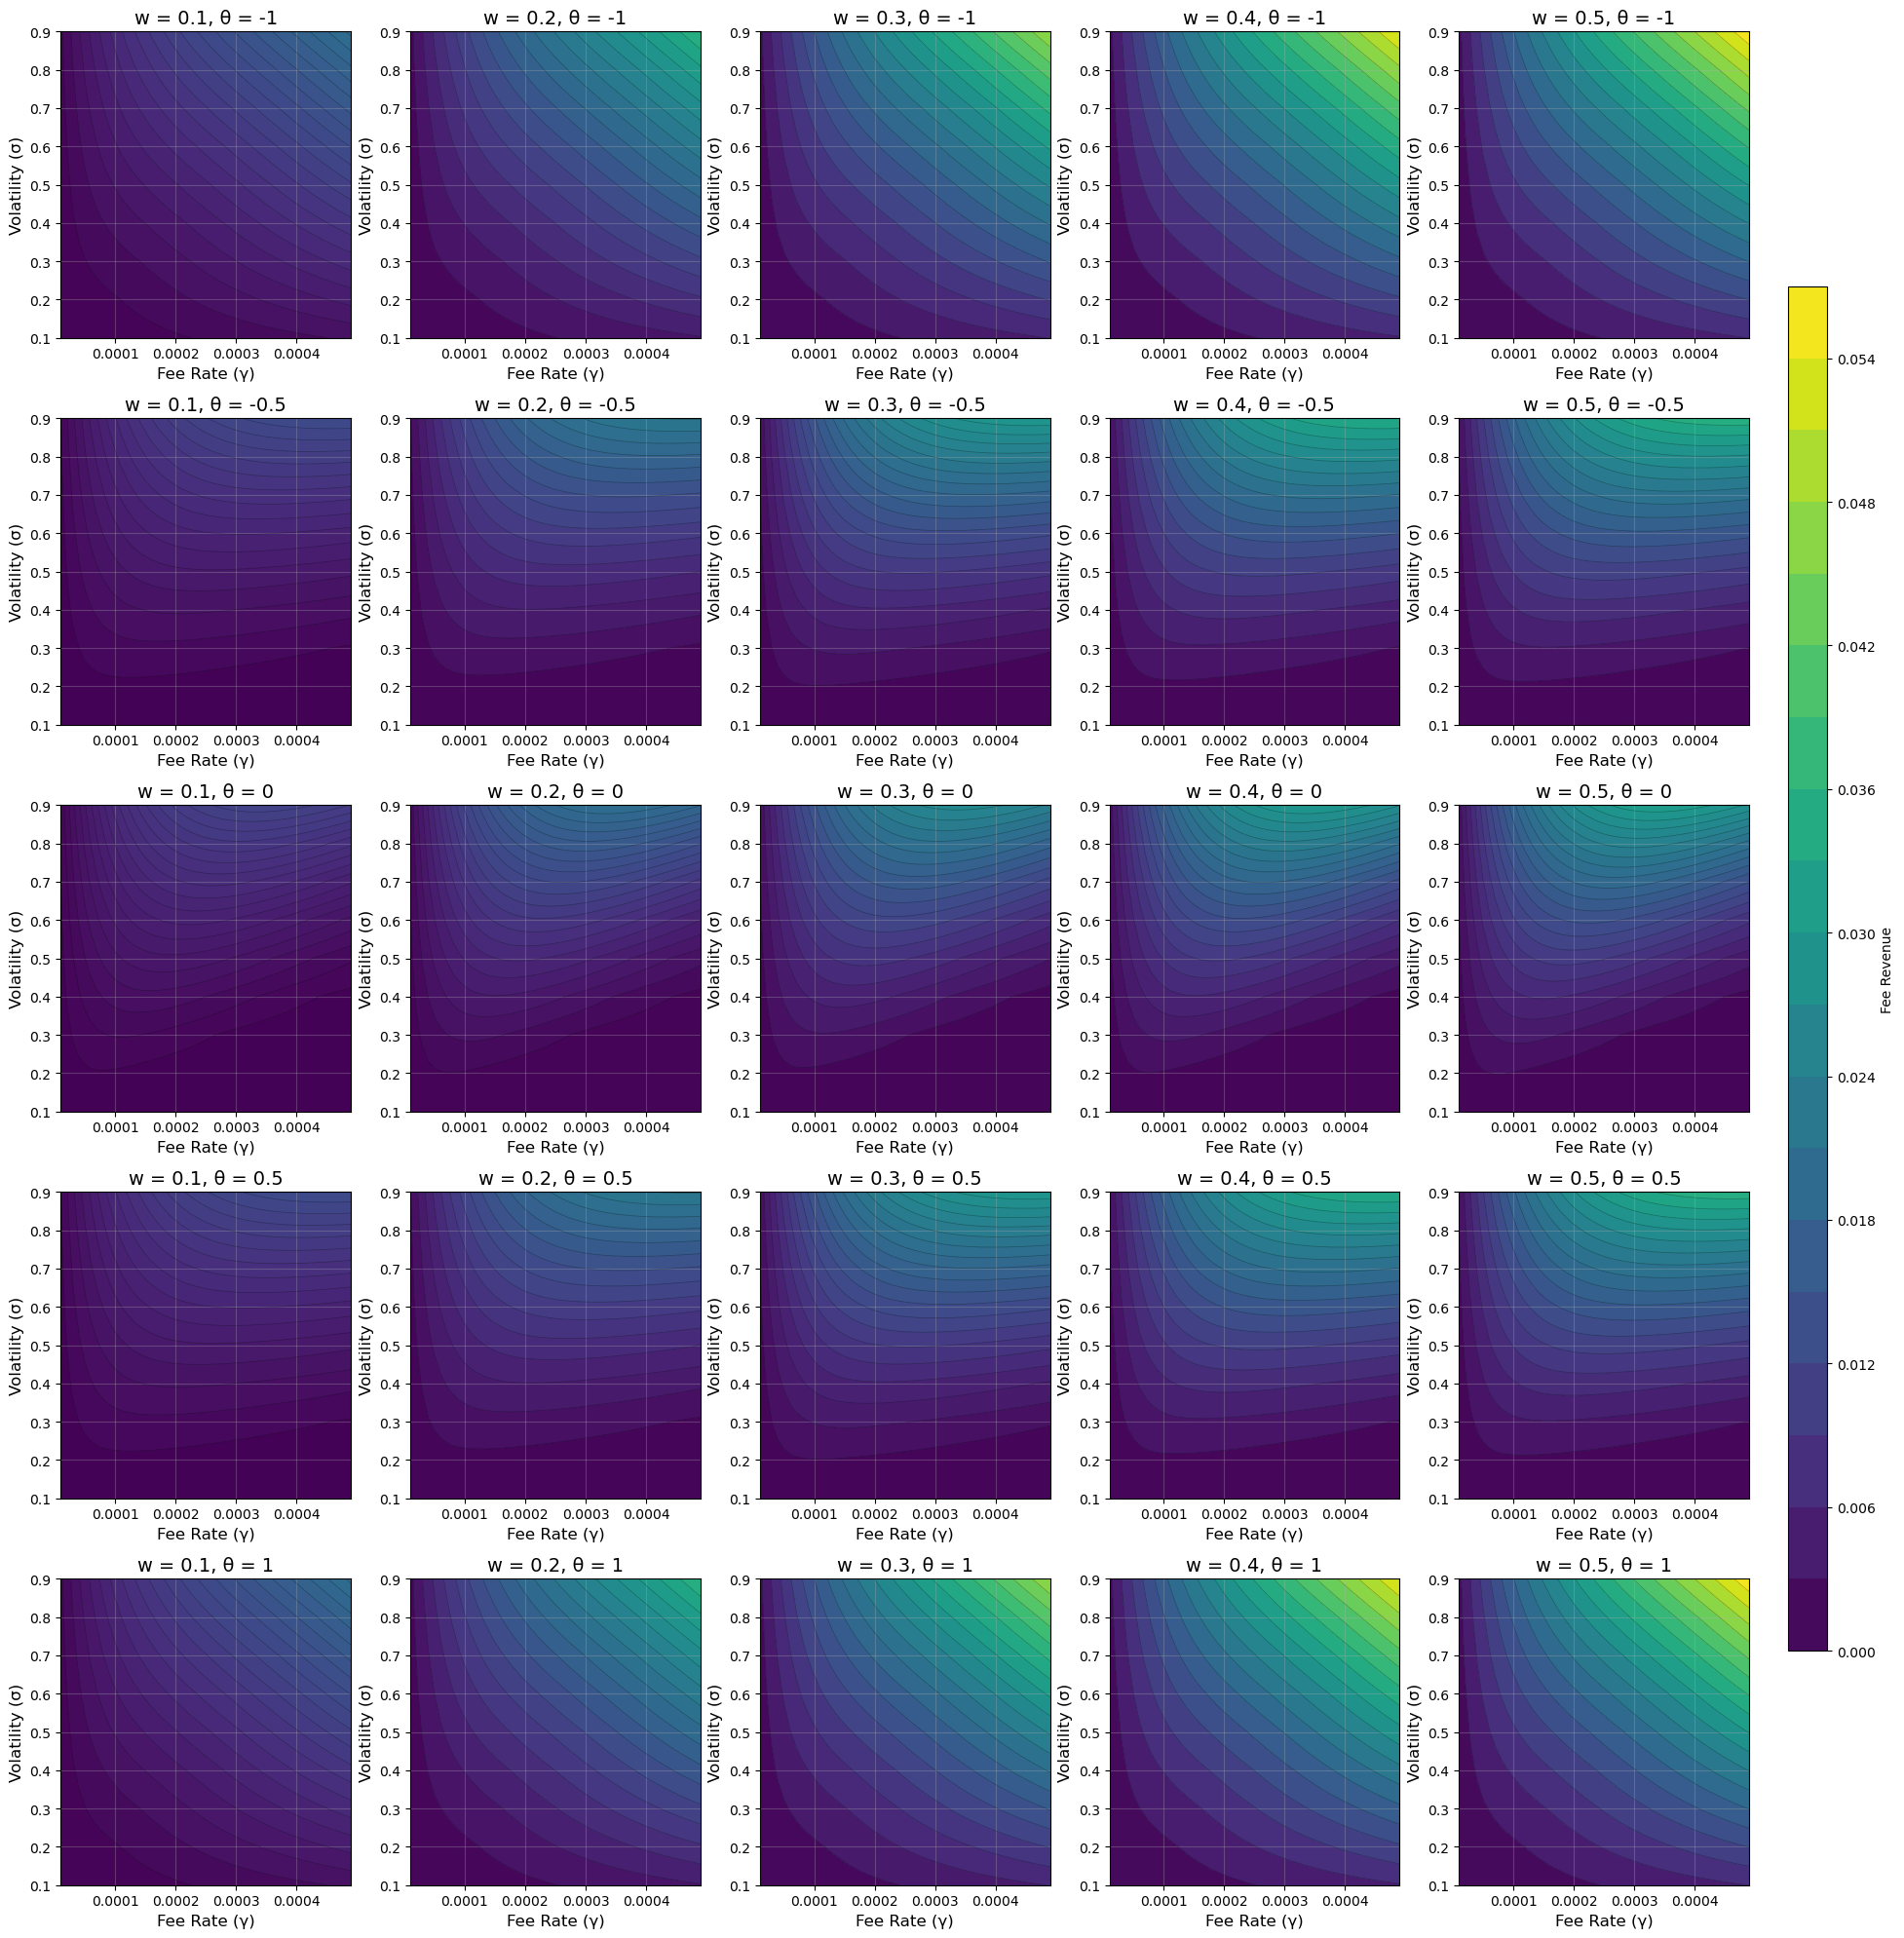

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from g3m import calculate_G3M_expected_fee

sigmas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
gammas = np.round(np.arange(0.00001, 0.0005, 0.00001), 5)
w_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
theta_values = [-1, -0.5, 0, 0.5, 1]
delta_t = 12/(365*24*60*60)
pv_0 = 2e6
L = 1e6
results = []
total_comb = len(sigmas) * len(w_values) * len(gammas) * len(theta_values)
progress_bar = tqdm(total=total_comb, desc="Processing combinations")

for sigma in sigmas:
    for w in w_values:
        for gamma in gammas:
            for theta in theta_values:
                incoming_fee, outgoing_fee = calculate_G3M_expected_fee(sigma, w, gamma, pv_0, L, delta_t, theta=theta)
                results.append({
                    'sigma': sigma,
                    'w': w,
                    'gamma': gamma,
                    'theta': theta,
                    'incoming_fee': incoming_fee,
                    'outgoing_fee': outgoing_fee
                })
                progress_bar.update(1)

progress_bar.close()

fee_df = pd.DataFrame(results)

# Create figure with 3x3 subplots
fig, axes = plt.subplots(5, 5, figsize=(20, 20))

# Define the w and theta values we want to plot
w_values_to_plot = [0.1, 0.2, 0.3, 0.4, 0.5]
theta_values_to_plot = [-1, -0.5, 0, 0.5, 1]  # Reversed order for better visualization

# Store min and max values for consistent colorbar scale
vmin = fee_df['outgoing_fee'].min()
vmax = fee_df['outgoing_fee'].max()

# Create subplots
for i, theta in enumerate(theta_values_to_plot):
    for j, w in enumerate(w_values_to_plot):
        ax = axes[i, j]
        
        # Filter data for this w and theta
        filtered_data = fee_df[(fee_df['w'] == w) & (fee_df['theta'] == theta)]
        
        # Create pivot table
        pivot_table = filtered_data.pivot_table(
            values='incoming_fee',  # Using outgoing_fee as the metric
            index='sigma',
            columns='gamma',
            aggfunc='mean'
        )
        
        # Create meshgrid
        sigma_vals = pivot_table.index.values
        gamma_vals = pivot_table.columns.values
        X, Y = np.meshgrid(gamma_vals, sigma_vals)
        
        # Create contour plot
        contour = ax.contourf(X, Y, pivot_table.values, levels=20, cmap='viridis',
                             vmin=vmin, vmax=vmax)
        
        # Add contour lines
        ax.contour(X, Y, pivot_table.values, levels=20, colors='k', alpha=0.3, linewidths=0.5)
        
        # Customize subplot
        ax.set_xlabel('Fee Rate (γ)', fontsize=12)
        ax.set_ylabel('Volatility (σ)', fontsize=12)
        ax.set_title(f'w = {w:.1f}, θ = {theta}', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=10)

# Add colorbar to the right of the subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(contour, cax=cbar_ax, label='Fee Revenue')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=0.9)

plt.show()


Processing combinations: 100%|██████████| 5427/5427 [00:01<00:00, 3867.49it/s]



Dataset Overview:
Total number of combinations: 5427

Value ranges:
Gamma: 0.000300 to 0.000700
Theta: -1.00 to 1.00
Total Fee Range: 0.00 to 0.16


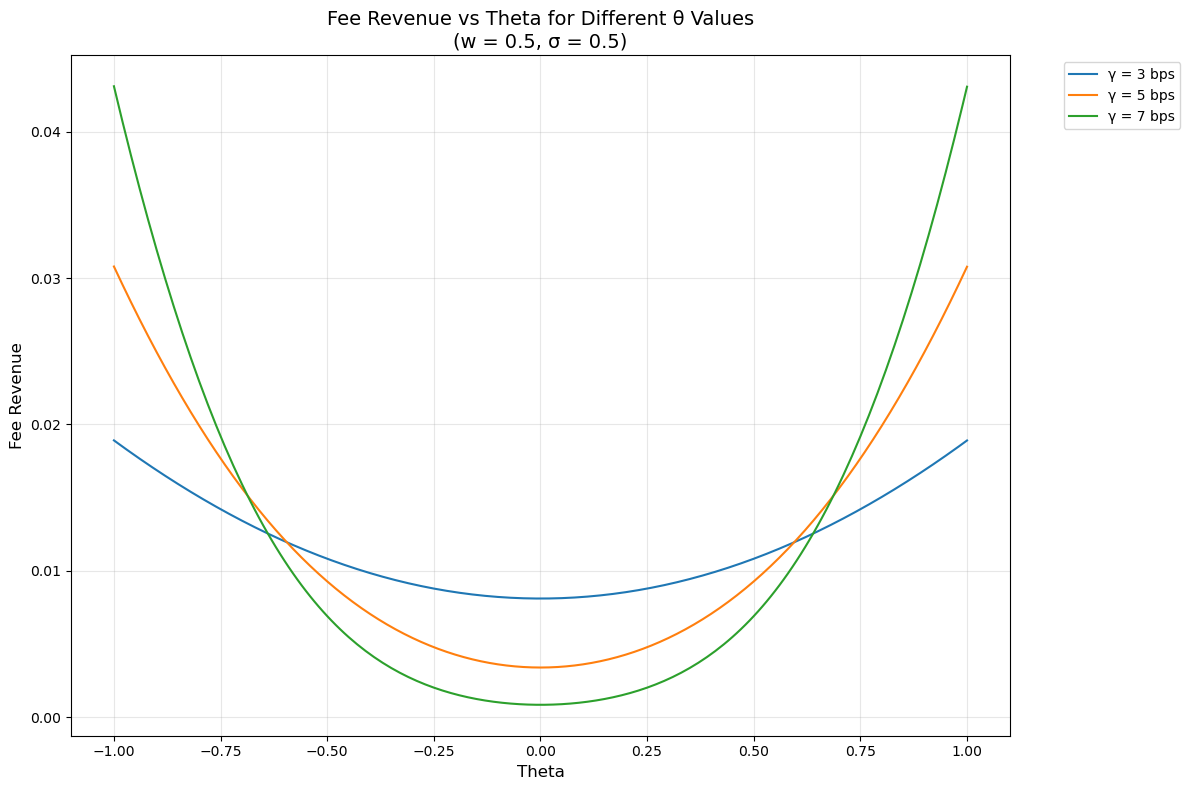

In [24]:

# Parameters for data collection
sigmas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
gammas = [0.0003, 0.0005, 0.0007]
theta_values = np.round(np.arange(-1, 1.01, 0.01), 2)
w_fixed = 0.5
delta_t = 12/(365*24*60*60)
pv_0 = 2e6
L = 1e6
w = 0.5

# Prepare to collect results
results = []
total_comb = len(sigmas) * len(gammas) * len(theta_values)
progress_bar = tqdm(total=total_comb, desc="Processing combinations")

# Collect data
for sigma in sigmas:
    for gamma in gammas:
        for theta in theta_values:
            incoming_fee, outgoing_fee = calculate_G3M_expected_fee(sigma, w_fixed, gamma, pv_0, L, delta_t, theta=theta)
            results.append({
                'sigma': sigma,
                'gamma': gamma,
                'theta': theta,
                'incoming_fee': incoming_fee,
                'outgoing_fee': outgoing_fee,
                'total_fee': incoming_fee + outgoing_fee
            })
            progress_bar.update(1)

progress_bar.close()

# Convert to DataFrame
new_fee_df = pd.DataFrame(results)

# Display some basic statistics
print("\nDataset Overview:")
print(f"Total number of combinations: {len(new_fee_df)}")
print("\nValue ranges:")
print(f"Gamma: {new_fee_df['gamma'].min():.6f} to {new_fee_df['gamma'].max():.6f}")
print(f"Theta: {new_fee_df['theta'].min():.2f} to {new_fee_df['theta'].max():.2f}")
print(f"Total Fee Range: {new_fee_df['total_fee'].min():.2f} to {new_fee_df['total_fee'].max():.2f}")
# Create a new figure
plt.figure(figsize=(12, 8))

# # Create a color map for different theta values
# colors = plt.cm.viridis(np.linspace(0, 1, len(theta_values)))

for gamma in gammas:
    selected_data = new_fee_df[
        (new_fee_df['sigma'] == 0.5) &
        (new_fee_df['gamma'] == gamma)
    ]
    # use base point for the gamma in the label
    plt.plot(selected_data['theta'], selected_data['incoming_fee'], label=f'γ = {gamma * 10000:.0f} bps')

plt.xlabel('Theta', fontsize=12)
plt.ylabel('Fee Revenue', fontsize=12)
plt.title(f'Fee Revenue vs Theta for Different θ Values\n(w = {w_fixed}, σ = {sigma_fixed})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()